2023 data discription:
count    8760.000000
mean      196.206318
std       291.964047
min         0.000000
25%         0.030290
50%         2.115971
75%       326.872749
max      1130.473193
Name: Datan Power Plant Solar Photovoltaic Hourly Power Generation (kW), dtype: float64 

2024 data discription:
count    8785.000000
mean      201.470936
std       283.127828
min         0.000000
25%         0.079664
50%        19.066827
75%       402.162813
max      1113.053279
Name: Datan Power Plant Solar Photovoltaic Hourly Power Generation (kW), dtype: float64 



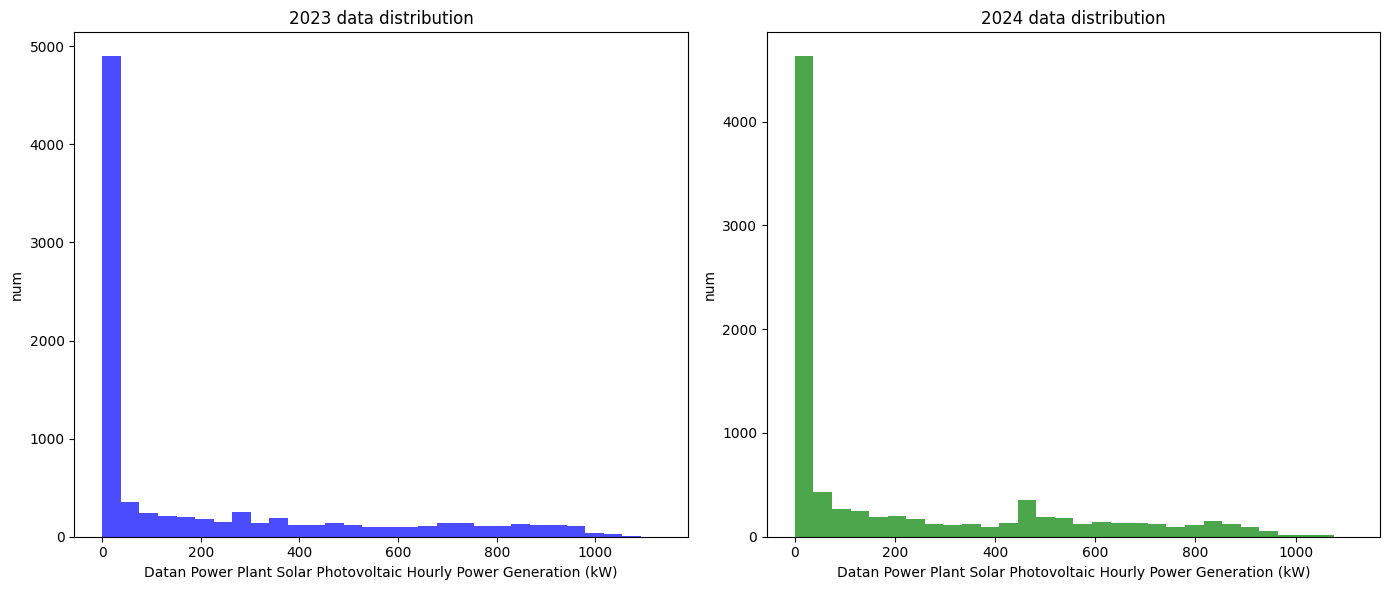

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 文件路径
file_2023 = "/content/大潭光電資料_填補後2023.csv"
file_2024 = "/content/大潭光電資料_填補後2024.csv"

# 加载数据（根据实际编码选择编码方式）
df_2023 = pd.read_csv(file_2023, encoding="ISO-8859-1")
df_2024 = pd.read_csv(file_2024, encoding="ISO-8859-1")

# 目标列名称
column_name = "Datan Power Plant Solar Photovoltaic Hourly Power Generation (kW)"

# 输出描述性统计信息
print("2023 data discription:")
print(df_2023[column_name].describe(), "\n")

print("2024 data discription:")
print(df_2024[column_name].describe(), "\n")

# 绘制直方图展示数据分布
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(df_2023[column_name].dropna(), bins=30, color='blue', alpha=0.7)
plt.title("2023 data distribution")
plt.xlabel(column_name)
plt.ylabel("num")

plt.subplot(1, 2, 2)
plt.hist(df_2024[column_name].dropna(), bins=30, color='green', alpha=0.7)
plt.title("2024 data distribution")
plt.xlabel(column_name)
plt.ylabel("num")

plt.tight_layout()
plt.show()


### Data Loading + Preprocessing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error

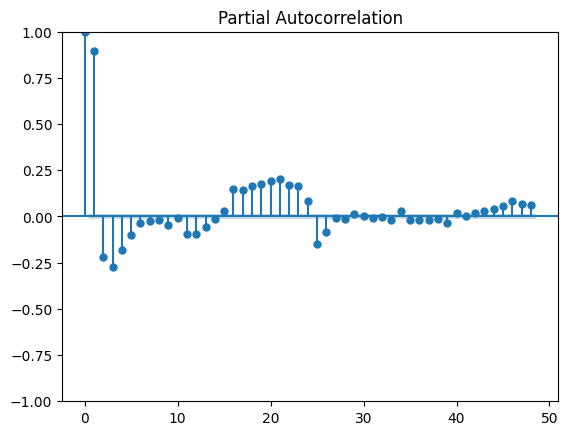

In [ ]:
import pandas as pd
from statsmodels.graphics.tsaplots import plot_pacf
data = pd.read_csv(file_path, encoding='ISO-8859-1')['Datan Power Plant Solar Photovoltaic Hourly Power Generation (kW)']
plot_pacf(data.dropna(), lags=48);


In [ ]:
file_path = "/content/datan_power_below200.csv"
data = pd.read_csv(file_path, encoding='ISO-8859-1')

# 删除无关列（例如"Unnamed: 0"和'Precipitation (mm)'）
data = data.drop(columns='ï»¿Unnamed: 0')#['Unnamed: 0', 'Precipitation (mm)']

# 分离特征与目标变量
X = data.drop(columns=['Datan Power Plant Solar Photovoltaic Hourly Power Generation (kW)'])
y = data['Datan Power Plant Solar Photovoltaic Hourly Power Generation (kW)']

# 标准化特征数据
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
data

,Station Pressure (hPa),Sea Level Pressure (hPa),Temperature (Â¢J),Dew Point Temperature (Â¢J),Relative Humidity (%),Wind Speed (m/s),Wind Direction (360-degree),Maximum Instantaneous Wind Speed (m/s),Maximum Instantaneous Wind Direction (360-degree),Precipitation Duration (h),Sunshine Duration (h),Global Solar Radiation (MJ/Â¢T),Visibility (km),Ultraviolet Index,Total Cloud Cover (0~10),Datan Power Plant Solar Photovoltaic Hourly Power Generation (kW)
0,1020.6,1023.2,20.7,17.9,84.0,9.3,50,15.6,50,0.0,0.0,1.00,30.0,2,9,279.793805
1,1020.2,1022.8,20.9,17.9,83.0,9.0,50,15.2,50,0.0,0.1,1.14,30.0,3,9,357.069324
2,1019.2,1021.7,21.5,18.7,84.0,9.1,50,15.3,60,0.0,0.2,1.68,30.0,4,9,342.948255
3,1018.4,1021.0,20.8,18.0,84.0,8.8,50,16.2,60,0.0,0.0,1.42,30.0,4,9,477.915136
4,1017.9,1020.5,20.7,18.3,86.0,10.3,50,16.7,40,0.0,0.0,1.22,30.0,3,9,446.673368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5744,1018.5,1021.1,17.9,8.8,55.0,9.6,50,18.2,50,0.0,0.4,1.73,16.0,4,7,505.301345
5745,1017.4,1020.0,18.4,8.4,52.0,10.2,50,16.9,50,0.0,0.7,2.21,16.0,5,7,639.152004
5746,1016.8,1019.4,18.2,9.0,55.0,10.1,50,16.6,50,0.0,1.0,2.16,12.0,4,2,809.523948
5747,1016.5,1019.1,17.3,7.9,54.0,11.5,50,18.2,50,0.0,1.0,1.66,12.0,3,2,683.074700


### Construct Time Series Data

In [ ]:
#固定種子
import random
seed = 42
np.random.seed(seed)
random.seed(seed)

# 将数据转换为时间序列格式，这里我们使用一个时间窗口来创建输入数据
def create_dataset(X, y, time_step=1):
    X_data, y_data = [], []
    for i in range(len(X) - time_step):
        X_data.append(X[i:i+time_step])
        y_data.append(y[i+time_step])
    return np.array(X_data), np.array(y_data)

# 使用窗口大小为24（你可以根据实际情况调整）
time_step = 12
X_seq, y_seq = create_dataset(X_scaled, y, time_step)

# 拆分数据集为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, shuffle=False, random_state=seed)


### Construct a CNN + Bi-LSTM Model

In [ ]:
'''from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout


model = Sequential()
# CNN层：使用一维卷积提取局部特征
model.add(Conv1D(filters=32, kernel_size=5, activation='relu', padding='same', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

# 池化层：降低特征维度，减少过拟合风险
model.add(MaxPooling1D(pool_size=2))
# 改為 return_sequences=True，可串接多層 LSTM
#model.add(Bidirectional(LSTM(units=50, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Bidirectional(LSTM(units=32, return_sequences=False, dropout=0.2, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2]))))

# 输出层：全连接层，输出一个数值（回归任务）
model.add(Dense(1))

# 编译模型
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')'''

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Construct a Bi-LSTM + CNN Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Input, LSTM, Flatten, Dense, Bidirectional

model = Sequential()

# 改為 return_sequences=True，可串接多層 LSTM
#model.add(Bidirectional(LSTM(units=50, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Bidirectional(LSTM(units=32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2]))))
model.add(MaxPooling1D(pool_size=2))

# CNN层：使用一维卷积提取局部特征
model.add(Conv1D(filters=32, kernel_size=5, activation='relu', padding='same', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

# 将多维数据展平为一维
model.add(Flatten())
# 输出层：全连接层，输出一个数值（回归任务）
model.add(Dense(1))

# 编译模型
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
'''from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout

model = Sequential()
# Bi-LSTM 层，返回整个时间序列
model.add(Bidirectional(LSTM(units=50, return_sequences=True), input_shape=(X_train.shape[1], X_train.shape[2])))
# CNN 层：使用一维卷积提取局部特征
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
# 池化层：降低特征维度，减少过拟合风险
model.add(MaxPooling1D(pool_size=2))
# 将多维数据展平为一维
model.add(Flatten())
# 输出层：全连接层，输出一个数值（回归任务）
model.add(Dense(1))

# 编译模型
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')'''


### CNN + Bi-LSTM + Attention

#### 模型二

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Layer
from tensorflow.keras.optimizers import Adam

# 自訂 Attention 層
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # input_shape: (batch_size, time_steps, features)
        self.W = self.add_weight(name='att_weight',
                                 shape=(input_shape[-1], input_shape[-1]),
                                 initializer='random_normal',
                                 trainable=True)
        self.b = self.add_weight(name='att_bias',
                                 shape=(input_shape[-1],),
                                 initializer='zeros',
                                 trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs: (batch_size, time_steps, features)
        # 對每個時間步進行線性變換後使用 tanh 激活函數
        e = tf.keras.backend.tanh(tf.keras.backend.dot(inputs, self.W) + self.b)
        # e 的 shape 為 (batch_size, time_steps, features)
        # 計算 attention score (softmax 在 time_steps 維度)
        a = tf.keras.backend.softmax(e, axis=1)
        # 將每個時間步的輸出與對應的注意力分數相乘
        output = inputs * a
        # 對 time_steps 維度求和，使得輸出 shape 為 (batch_size, features)
        return tf.keras.backend.sum(output, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

# 假設 X_train 已經準備好，且其 shape 為 (samples, time_steps, features)
# 範例模型：先使用 CNN 層，再用 Bi-LSTM，再加上 Attention 層，最後輸出預測結果
model = Sequential()
# CNN 層：使用一維卷積提取局部特徵
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

# 第二層 CNN 層
model.add(Conv1D(16, 3, activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# 池化層：降低特徵維度與噪音
#model.add(MaxPooling1D(pool_size=2))

# Bi-LSTM 層：返回所有時間步的輸出，便於後續進行 attention 機制
#model.add(Bidirectional(LSTM(units=50, return_sequences=True)))
model.add(Bidirectional(LSTM(units=32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2]))))

# Attention 層：聚合 Bi-LSTM 的時間步輸出
model.add(AttentionLayer())

# 輸出層：全連接層，回歸任務輸出一個數值
model.add(Dense(1))

# 編譯模型
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# 顯示模型結構
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 10, 32)         │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 5, 16)          │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 5, 16)          │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 2, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 2, 64)          │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_1               │ (None, 64)             │         4,160 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,985 (78.07 KB)

 Trainable params: 19,889 (77.69 KB)

 Non-trainable params: 96 (384.00 B)

### CNN + Attention + Bi-LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Multiply, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Dropout

# 自定义 Attention 层
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # 创建一个 Dense 层用于计算注意力权重
        self.attn_dense = Dense(input_shape[-1], activation='softmax')
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs: (batch_size, time_steps, features)
        # 使用预先定义的 Dense 层计算注意力权重
        att_weights = self.attn_dense(inputs)
        # 按元素乘法加权特征
        weighted_inputs = Multiply()([inputs, att_weights])
        return weighted_inputs

# 构建模型
model = Sequential()
# 输入层，形状为 (time_steps, features)
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
# 1. CNN 层：提取局部特征
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
# 池化层：降维、过滤噪声
model.add(MaxPooling1D(pool_size=2))
# 2. Attention 层：对 CNN 输出的特征加权
model.add(AttentionLayer())
# 3. Bi-LSTM 层：对经过 attention 加权的时序数据进行建模
model.add(Bidirectional(LSTM(units=32, return_sequences=False, dropout=0.2, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2]))))

# 4. 全连接输出层：回归预测输出单个数值
model.add(Dense(1))

# 编译模型
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 5, 64)          │         4,160 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,001 (125.00 KB)

 Trainable params: 32,001 (125.00 KB)

 Non-trainable params: 0 (0.00 B)

### 訓練

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 1/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - loss: 2597.0435 - val_loss: 1568.9049
Epoch 2/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1844.7958 - val_loss: 1448.4354
Epoch 3/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1545.8538 - val_loss: 1111.2006
Epoch 4/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1271.3447 - val_loss: 895.4250
Epoch 5/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 1080.9492 - val_loss: 761.7941
Epoch 6/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 911.5908 - val_loss: 746.0682
Epoch 7/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 879.4937 - val_loss: 660.2546
Epoch 8/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 737.9727 - val_loss: 666.4901
Epoch 9/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 765.5338 - val_loss: 643.6838
Epoch 10/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 704.8877 - val_loss: 623.3076
Epoch 11/100
295/295 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 643.738

In [ ]:
loss = model.evaluate(X_test, y_test)
print(f"Model loss: {loss}")

# 预测测试集
predictions = model.predict(X_test)

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 600.0583
Model loss: 554.4899291992188
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


### 模型評估和預測

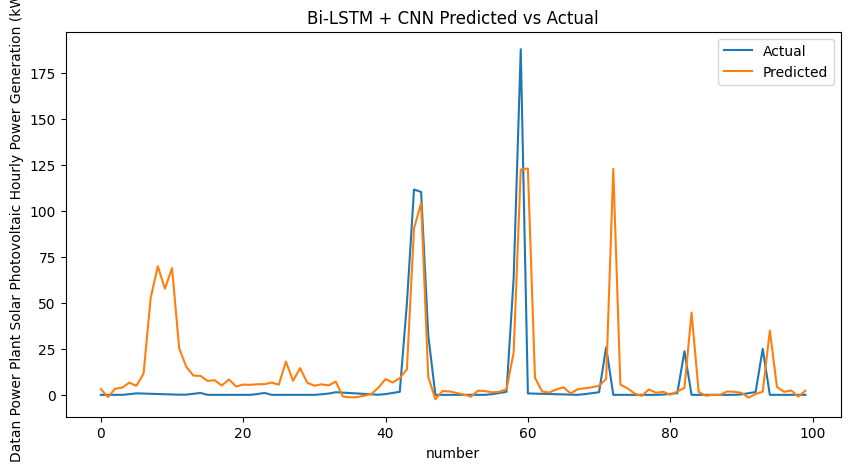

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test[:100], label='Actual')
plt.plot(predictions[:100], label='Predicted')
plt.xlabel('number')
plt.ylabel('Datan Power Plant Solar Photovoltaic Hourly Power Generation (kW)')
plt.title('Bi-LSTM + CNN Predicted vs Actual')
plt.legend()
plt.show()

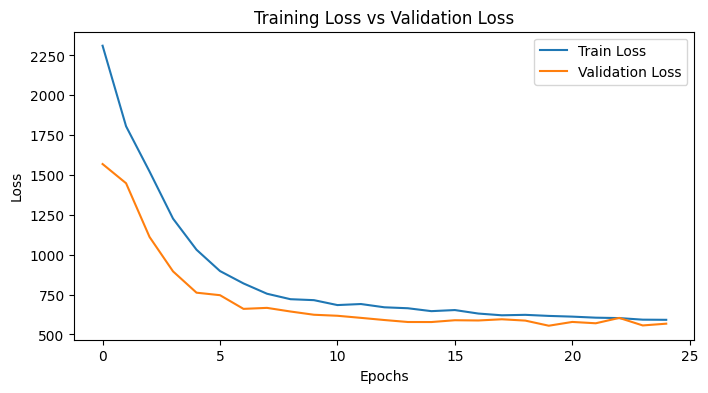

In [ ]:
# 绘制训练损失和验证损失曲线
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 計算 MAE（平均絕對誤差）
def mean_absolute_error_custom(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

# 計算 RMSE（均方根誤差）
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# 計算 MRE 或 MAPE（可選乘100）
def mean_relative_error_custom(y_true, y_pred, multiply_100=False, threshold=130):
    """
    y_true: 真實值
    y_pred: 預測值
    multiply_100: 如果為True，結果乘100（計算MAPE用）
    threshold: 小於這個值的 y_true 會被排除，避免除以接近零的數字
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # 防止除以0或極小值
    non_zero_mask = np.abs(y_true) > threshold

    if not np.any(non_zero_mask):
        return np.nan  # 如果全被排掉，回傳NaN

    relative_error = np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])
    result = np.mean(relative_error)

    if multiply_100:
        result *= 100

    return result

#計算R平方
def r2_custom(y_true, y_pred):
    return r2_score(y_true, y_pred)

# 计算误差指标
mre = mean_relative_error_custom(y_test, predictions, multiply_100=False)
mape = mean_relative_error_custom(y_test, predictions, multiply_100=True)
mae = mean_absolute_error_custom(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
r2 = r2_custom(y_test, predictions)


# 打印各项指标
print(f"Mean Relative Error (MRE): {mre:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")
print(f"R² (Coefficient of Determination): {r2:.4f}")

Mean Relative Error (MRE): 0.3507
Mean Absolute Error (MAE): 10.7821
Root Mean Squared Error (RMSE): 23.5476
Mean Absolute Percentage Error (MAPE): 35.0740%
R² (Coefficient of Determination): 0.6768


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
# from tensorflow.keras.models import load_model  # 若要從檔案載入模型再打開
# model = load_model("your_model_path.h5")

# ===== Parameters =====
file_path = "/content/大潭光電資料_填補後2024_天氣資料.csv"  # your file path
target_col = "Datan Power Plant Solar Photovoltaic Hourly Power Generation (kW)"
window_size = 12
predict_next = True  # True: use past 12 steps to predict next; False: predict current step

# ===== Robust CSV Reading (handle Chinese encoding) =====
def read_csv_robust(path):
    for enc in ["big5", "cp950", "utf-8"]:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass
    return pd.read_csv(path)  # fallback

data = read_csv_robust(file_path)

# ===== Keep numeric columns, split X / y =====
numeric_df = data.select_dtypes(include=[np.number]).copy()
if target_col not in numeric_df.columns:
    raise ValueError(f"Target column not found: {target_col}\nAvailable columns: {list(data.columns)}")

y_all = numeric_df[target_col].to_numpy(dtype=float)
X_all = numeric_df.drop(columns=[target_col]).to_numpy(dtype=float)
feature_cols = numeric_df.drop(columns=[target_col]).columns.tolist()
print(f"Number of features: {len(feature_cols)} (model input last dimension must match)")

# ===== StandardScaler (must match training scaler) =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# ===== Convert to (samples, window, features) =====
def make_sequences(X2d, y1d, win, predict_next=True):
    N, F = X2d.shape
    X_seq, y_seq = [], []
    if predict_next:
        for i in range(win - 1, N - 1):
            X_seq.append(X2d[i - win + 1:i + 1])
            y_seq.append(y1d[i + 1])
    else:
        for i in range(win - 1, N):
            X_seq.append(X2d[i - win + 1:i + 1])
            y_seq.append(y1d[i])
    return np.array(X_seq), np.array(y_seq)

X_3d, y_aligned = make_sequences(X_scaled, y_all, window_size, predict_next=predict_next)
print("X_3d shape:", X_3d.shape)  # (M, 12, F)
print("y_aligned shape:", y_aligned.shape)

# ===== Prediction =====
# assume you already have `model` (e.g., LSTM/CNN with input shape (None, 12, features))
y_pred = model.predict(X_3d, verbose=0).reshape(-1)

# ===== Align predictions back to original DataFrame index =====
if predict_next:
    base_idx = np.arange(window_size, len(numeric_df))
else:
    base_idx = np.arange(window_size - 1, len(numeric_df))

result = data.copy()
result["Predicted Power Generation (kW)"] = np.nan
result["Actual Power Generation (Aligned) (kW)"] = np.nan
result.loc[result.index[base_idx], "Predicted Power Generation (kW)"] = y_pred
result.loc[result.index[base_idx], "Actual Power Generation (Aligned) (kW)"] = y_aligned

# ===== Evaluation =====
try:
    mae = mean_absolute_error(y_aligned, y_pred)
    r2 = r2_score(y_aligned, y_pred)
    print(f"MAE: {mae:.4f}, R²: {r2:.4f}")
except Exception as e:
    print("Error calculating metrics:", e)

# ===== Output =====
out_path = "/content/Power_Generation_Prediction_StandardScaler.csv"
result.to_csv(out_path, index=False)
print(f"✅ Output saved: {out_path}")


FileNotFoundError: [Errno 2] No such file or directory: '/content/大潭光電資料_填補後2024_天氣資料.csv'

In [ ]:
'''def mean_relative_error(y_true, y_pred):
    # 避免除零错误
    non_zero_mask = y_true != 0
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask]))

def mean_absolute_percentage_error(y_true, y_pred):
    non_zero_mask = y_true != 0
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mre = mean_relative_error(y_test, predictions)
mape = mean_absolute_percentage_error(y_test, predictions)

print(f"Mean Relative Error (MRE): {mre:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}%")'''

Mean Relative Error (MRE): 2016.2193
Mean Absolute Error (MAE): 46.1475
Root Mean Squared Error (RMSE): 86.5350
Mean Absolute Percentage Error (MAPE): 201621.9348%
